# Cryptocurrency Liquidity Prediction for Market Stability

## Machine Learning Project

**Objective:** Predict next-day cryptocurrency liquidity using the supplied CoinGecko datasets.

The project brief asks for data preprocessing, EDA, feature engineering, model selection, model training, evaluation using RMSE/MAE/R², and testing/validation. It also asks for liquidity-related features such as moving averages, volatility, and liquidity ratios.

**Important dataset note:** The supplied CSV files contain market data for **2022-03-16** and **2022-03-17**. The project brief mentions historical data from 2016 and 2017, but this notebook uses the datasets actually supplied with the project. The supplied data does not contain social-media activity or exchange-listing fields, so those factors are not used.


## 1. Import Libraries

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load the Supplied Datasets

The notebook expects both CSV files to be in the same folder as the notebook:

- `coin_gecko_2022-03-16.csv`
- `coin_gecko_2022-03-17.csv`


In [7]:
import os
from google.colab import files

file_16 = "coin_gecko_2022-03-16.csv"
file_17 = "coin_gecko_2022-03-17.csv"

# Check if files exist, if not, prompt for upload
if not os.path.exists(file_16) or not os.path.exists(file_17):
    print("One or more data files are missing. Please upload them now.")
    uploaded = files.upload()

# Load the datasets
df_16 = pd.read_csv(file_16)
df_17 = pd.read_csv(file_17)

print("16 March shape:", df_16.shape)
print("17 March shape:", df_17.shape)

display(df_16.head())
display(df_17.head())


16 March shape: (500, 9)
17 March shape: (500, 9)


,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,2022-03-16
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,2022-03-16
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,2022-03-16
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,2022-03-16
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,2022-03-16


,coin,symbol,price,1h,24h,7d,24h_volume,mkt_cap,date
0,Bitcoin,BTC,40851.380000,0.001,0.000,-0.027,2.047612e+10,7.760774e+11,2022-03-17
1,Ethereum,ETH,2824.420000,0.004,0.029,0.034,1.364041e+10,3.390772e+11,2022-03-17
2,Tether,USDT,1.000000,-0.000,0.000,0.000,4.413140e+10,8.020588e+10,2022-03-17
3,BNB,BNB,389.610000,0.002,0.016,-0.010,1.425354e+09,6.556116e+10,2022-03-17
4,USD Coin,USDC,0.999739,-0.001,0.000,-0.000,3.569816e+09,5.259607e+10,2022-03-17


## 3. Understand the Dataset

In [8]:
print("Columns:")
print(df_16.columns.tolist())

print("\nData types:")
display(df_16.dtypes)

print("\nMissing values - 16 March:")
display(df_16.isnull().sum())

print("\nMissing values - 17 March:")
display(df_17.isnull().sum())

print("\nDuplicate rows - 16 March:", df_16.duplicated().sum())
print("Duplicate rows - 17 March:", df_17.duplicated().sum())


Columns:
['coin', 'symbol', 'price', '1h', '24h', '7d', '24h_volume', 'mkt_cap', 'date']

Data types:


,0
coin,object
symbol,object
price,float64
1h,float64
24h,float64
7d,float64
24h_volume,float64
mkt_cap,float64
date,object



Missing values - 16 March:


,0
coin,0
symbol,0
price,0
1h,3
24h,3
7d,3
24h_volume,3
mkt_cap,0
date,0



Missing values - 17 March:


,0
coin,0
symbol,0
price,0
1h,4
24h,4
7d,5
24h_volume,4
mkt_cap,0
date,0



Duplicate rows - 16 March: 0
Duplicate rows - 17 March: 0


## 4. Data Preprocessing

The dataset contains `coin`, `symbol`, `price`, percentage-change fields, 24-hour volume, market capitalization, and date.

For this project, **liquidity ratio** is engineered as:

`liquidity_ratio = 24h_volume / market_cap`

A higher ratio indicates that a larger amount of the market capitalization is being traded during the 24-hour period.


In [9]:
def preprocess(df):
    df = df.copy()
    numeric_cols = ["price", "1h", "24h", "7d", "24h_volume", "mkt_cap"]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.drop_duplicates()

    df["liquidity_ratio"] = df["24h_volume"] / df["mkt_cap"].replace(0, np.nan)
    df["volume_to_price"] = df["24h_volume"] / df["price"].replace(0, np.nan)

    return df.replace([np.inf, -np.inf], np.nan)

df_16 = preprocess(df_16)
df_17 = preprocess(df_17)

print("Missing values after preprocessing:")
display(df_16.isnull().sum())


Missing values after preprocessing:


,0
coin,0
symbol,0
price,0
1h,3
24h,3
7d,3
24h_volume,3
mkt_cap,0
date,0
liquidity_ratio,3


## 5. Exploratory Data Analysis (EDA)

In [10]:
print("16 March descriptive statistics:")
display(df_16.describe())

print("17 March descriptive statistics:")
display(df_17.describe())


16 March descriptive statistics:


,price,1h,24h,7d,24h_volume,mkt_cap,date,liquidity_ratio,volume_to_price
count,5.000000e+02,497.000000,497.000000,497.000000,4.970000e+02,5.000000e+02,500,497.000000,4.970000e+02
mean,6.527851e+02,0.018746,0.028849,0.039016,3.276644e+08,3.722677e+09,2022-03-16 00:00:00,0.106845,1.800642e+13
min,1.544000e-09,-0.039000,-0.141000,-0.547000,0.000000e+00,6.577043e+07,2022-03-16 00:00:00,0.000000,0.000000e+00
25%,1.904625e-01,0.011000,0.004000,-0.020000,1.838591e+06,1.146391e+08,2022-03-16 00:00:00,0.008940,7.520545e+05
50%,1.085000e+00,0.018000,0.021000,0.006000,8.581305e+06,2.083208e+08,2022-03-16 00:00:00,0.036105,9.469724e+06
75%,6.925000e+00,0.026000,0.040000,0.049000,4.075655e+07,5.845642e+08,2022-03-16 00:00:00,0.091972,7.741704e+07
max,4.121727e+04,0.086000,0.573000,2.935000,5.793497e+10,7.709915e+11,2022-03-16 00:00:00,4.833200,4.601624e+15
std,4.578529e+03,0.013867,0.058065,0.203688,3.182264e+09,3.784349e+10,NaN,0.351555,2.654744e+14


17 March descriptive statistics:


,price,1h,24h,7d,24h_volume,mkt_cap,date,liquidity_ratio,volume_to_price
count,5.000000e+02,496.000000,496.000000,495.000000,4.960000e+02,5.000000e+02,500,4.960000e+02,4.960000e+02
mean,6.594269e+02,0.000681,0.018615,0.008038,2.508801e+08,3.787932e+09,2022-03-17 00:00:00,1.006341e-01,1.585862e+13
min,1.484000e-09,-0.704000,-0.646000,-0.558000,4.349000e+01,6.731896e+07,2022-03-17 00:00:00,9.722859e-08,6.160129e+00
25%,2.043850e-01,-0.001000,0.000000,-0.051500,1.757171e+06,1.194822e+08,2022-03-17 00:00:00,8.580264e-03,6.515161e+05
50%,1.100000e+00,0.001000,0.011000,-0.014000,7.890414e+06,2.168525e+08,2022-03-17 00:00:00,3.188708e-02,7.791198e+06
75%,7.435000e+00,0.004000,0.030000,0.020000,3.638643e+07,6.091268e+08,2022-03-17 00:00:00,7.718603e-02,6.323116e+07
max,4.090907e+04,0.095000,0.577000,4.608000,4.413140e+10,7.760774e+11,2022-03-17 00:00:00,5.948545e+00,3.996208e+15
std,4.595355e+03,0.033128,0.060142,0.252549,2.285948e+09,3.826905e+10,NaN,3.820498e-01,2.376163e+14


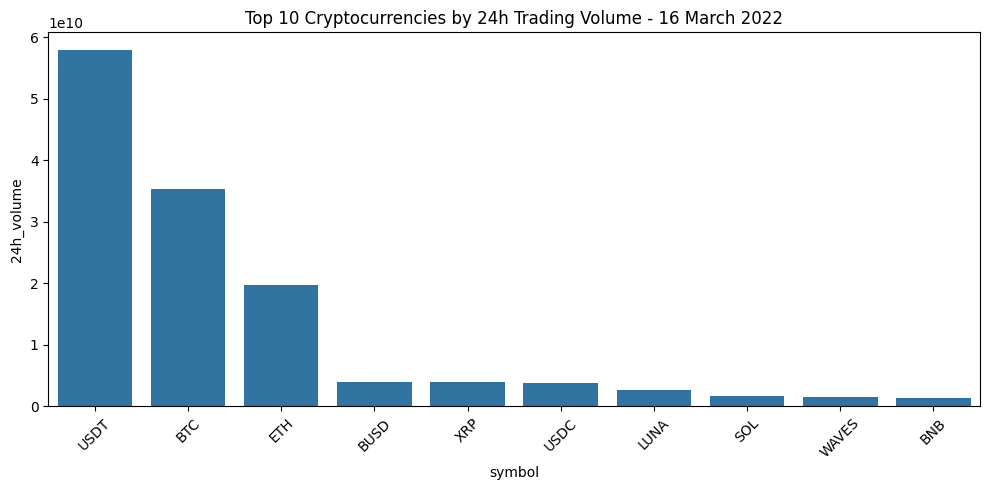

In [11]:
top_volume = df_16.nlargest(10, "24h_volume")[["coin", "symbol", "24h_volume"]]

plt.figure(figsize=(10, 5))
sns.barplot(data=top_volume, x="symbol", y="24h_volume")
plt.title("Top 10 Cryptocurrencies by 24h Trading Volume - 16 March 2022")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


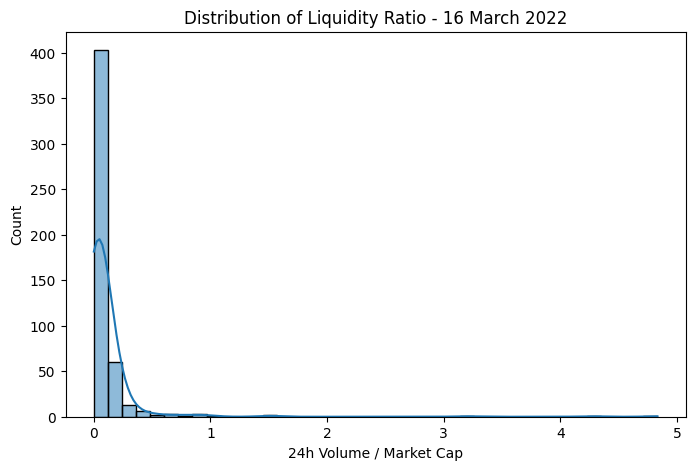

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df_16["liquidity_ratio"].dropna(), bins=40, kde=True)
plt.title("Distribution of Liquidity Ratio - 16 March 2022")
plt.xlabel("24h Volume / Market Cap")
plt.show()


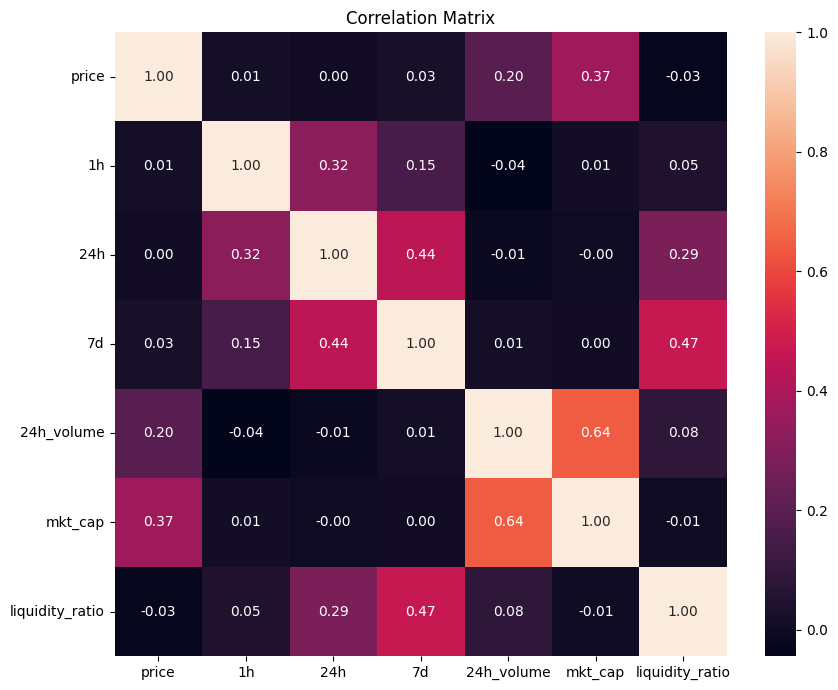

In [13]:
corr_cols = ["price", "1h", "24h", "7d", "24h_volume", "mkt_cap", "liquidity_ratio"]
plt.figure(figsize=(9, 7))
sns.heatmap(df_16[corr_cols].corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 6. Feature Engineering

Because the goal is to forecast liquidity for the next day, the features come from **16 March** and the target comes from **17 March**.

The target is:

`17 March liquidity_ratio = 17 March 24h_volume / 17 March market_cap`

This avoids using 17 March volume or market capitalization as input features.


In [14]:
features_16 = [
    "price", "1h", "24h", "7d",
    "24h_volume", "mkt_cap",
    "liquidity_ratio", "volume_to_price"
]

left = df_16[["coin", "symbol"] + features_16].copy()
right = df_17[["coin", "symbol", "liquidity_ratio"]].copy()

left = left.rename(columns={c: c + "_16" for c in features_16})
right = right.rename(columns={"liquidity_ratio": "liquidity_ratio_17"})

model_df = left.merge(right, on=["coin", "symbol"], how="inner")
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

print("Modeling dataset shape:", model_df.shape)
display(model_df.head())


Modeling dataset shape: (490, 11)


,coin,symbol,price_16,1h_16,24h_16,7d_16,24h_volume_16,mkt_cap_16,liquidity_ratio_16,volume_to_price_16,liquidity_ratio_17
0,Bitcoin,BTC,40859.460000,0.022,0.030,0.055,3.539076e+10,7.709915e+11,0.045903,8.661584e+05,0.026384
1,Ethereum,ETH,2744.410000,0.024,0.034,0.065,1.974870e+10,3.271044e+11,0.060374,7.195971e+06,0.040228
2,Tether,USDT,1.000000,-0.001,-0.001,0.000,5.793497e+10,7.996516e+10,0.724503,5.793497e+10,0.550227
3,BNB,BNB,383.430000,0.018,0.028,0.004,1.395854e+09,6.404382e+10,0.021795,3.640440e+06,0.021741
4,USD Coin,USDC,0.999874,-0.001,0.000,-0.000,3.872274e+09,5.222214e+10,0.074150,3.872762e+09,0.067872


## 7. Create Training and Testing Data

There are only two supplied dates, so a true long historical time-series split is not possible with this dataset. Instead, each cryptocurrency's 16 March observations are used to predict its 17 March liquidity.

An 80/20 train-test split is used to evaluate generalization across cryptocurrencies.


In [15]:
feature_cols = [c + "_16" for c in features_16]
X = model_df[feature_cols]
y = model_df["liquidity_ratio_17"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 392
Testing samples: 98


## 8. Model 1 - Random Forest Regressor

In [16]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)


Random Forest
MAE : 0.05575239247742901
RMSE: 0.3484642286775833
R²  : 0.6597609027022179


## 9. Model 2 - Gradient Boosting Regressor

In [17]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)


Gradient Boosting
MAE : 0.053423202194488796
RMSE: 0.3294369006740714
R²  : 0.6959028854796139


## 10. Compare Models

In [18]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "MAE": [rf_mae, gb_mae],
    "RMSE": [rf_rmse, gb_rmse],
    "R2": [rf_r2, gb_r2]
})

display(results)

best_model_name = results.loc[results["RMSE"].idxmin(), "Model"]
print("Selected model based on lowest RMSE:", best_model_name)


,Model,MAE,RMSE,R2
0,Random Forest,0.055752,0.348464,0.659761
1,Gradient Boosting,0.053423,0.329437,0.695903


Selected model based on lowest RMSE: Gradient Boosting


## 11. Feature Importance

Feature importance helps identify which 16 March market variables contributed most to the Gradient Boosting prediction.


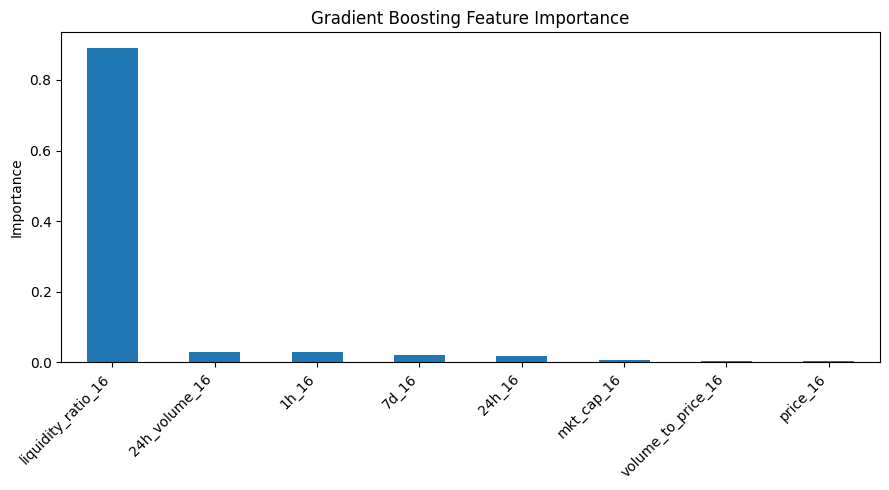

,importance
liquidity_ratio_16,0.890481
24h_volume_16,0.029092
1h_16,0.029029
7d_16,0.021404
24h_16,0.016738
mkt_cap_16,0.005240
volume_to_price_16,0.004312
price_16,0.003705


In [19]:
importance = pd.Series(
    gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
importance.plot(kind="bar")
plt.title("Gradient Boosting Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(importance.to_frame("importance"))


## 12. Actual vs Predicted Liquidity

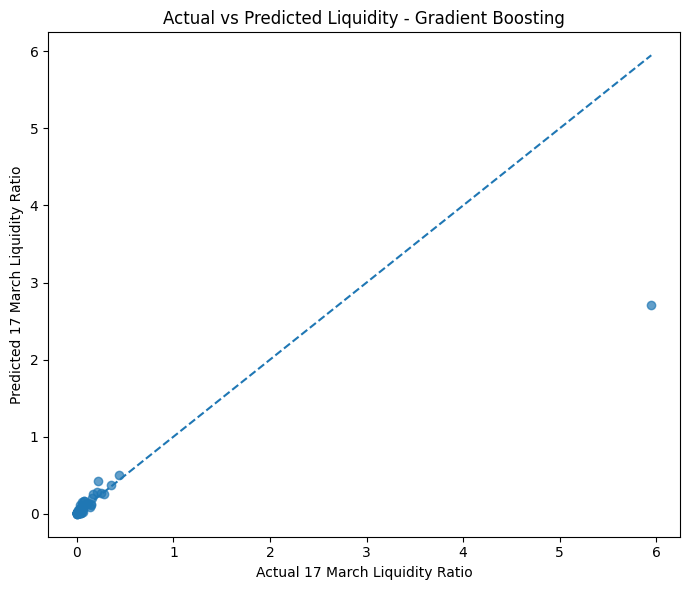

In [20]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, gb_pred, alpha=0.7)
plt.xlabel("Actual 17 March Liquidity Ratio")
plt.ylabel("Predicted 17 March Liquidity Ratio")
plt.title("Actual vs Predicted Liquidity - Gradient Boosting")

min_val = min(y_test.min(), gb_pred.min())
max_val = max(y_test.max(), gb_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.tight_layout()
plt.show()


## 13. Error Analysis

In [21]:
predictions = model_df.loc[X_test.index, ["coin", "symbol"]].copy()
predictions["actual_liquidity"] = y_test
predictions["predicted_liquidity"] = gb_pred
predictions["absolute_error"] = np.abs(
    predictions["actual_liquidity"] - predictions["predicted_liquidity"]
)

display(predictions.sort_values("absolute_error", ascending=False).head(15))


,coin,symbol,actual_liquidity,predicted_liquidity,absolute_error
409,JasmyCoin,JASMY,5.948545,2.707148,3.241397
383,DODO,DODO,0.217458,0.427904,0.210447
39,Monero,XMR,0.047871,0.147819,0.099948
75,TrueUSD,TUSD,0.068430,0.167311,0.098881
82,Basic Attention Token,BAT,0.162793,0.259490,0.096697
342,Metadium,META,0.077003,0.170543,0.093540
124,Ankr,ANKR,0.035782,0.116715,0.080933
11,Binance USD,BUSD,0.208483,0.275826,0.067343
362,Alien Worlds,TLM,0.434797,0.499576,0.064779
73,Bitcoin SV,BSV,0.055889,0.115149,0.059260


## 14. Predict Liquidity Level for All Supplied Cryptocurrencies

In [22]:
all_predictions = model_df[["coin", "symbol"]].copy()
all_predictions["predicted_liquidity_ratio_17"] = gb.predict(model_df[feature_cols])

# Convert the continuous ratio into simple descriptive levels.
# Thresholds are based on the distribution of predicted values in this supplied dataset.
q_low = all_predictions["predicted_liquidity_ratio_17"].quantile(0.33)
q_high = all_predictions["predicted_liquidity_ratio_17"].quantile(0.66)

def liquidity_level(x):
    if x <= q_low:
        return "Low"
    elif x <= q_high:
        return "Medium"
    return "High"

all_predictions["liquidity_level"] = all_predictions[
    "predicted_liquidity_ratio_17"
].apply(liquidity_level)

display(all_predictions.sort_values(
    "predicted_liquidity_ratio_17", ascending=False
).head(20))


,coin,symbol,predicted_liquidity_ratio_17,liquidity_level
186,FLEX Coin,FLEX,4.217647,High
182,STEPN,GMT,2.982075,High
409,JasmyCoin,JASMY,2.707148,High
407,Alpine F1 Team Fan Token,ALPINE,1.984784,High
438,HUNT,HUNT,1.138223,High
396,My Neighbor Alice,ALICE,0.917683,High
200,Nano,XNO,0.797503,High
436,Adventure Gold,AGLD,0.661470,High
421,Verasity,VRA,0.590234,High
2,Tether,USDT,0.531722,High


## 15. Final Findings

1. The supplied dataset provides price, percentage changes, 24-hour volume, market capitalization, coin/symbol, and date.
2. A liquidity ratio was engineered as `24h_volume / market_cap`.
3. The 16 March data was used to predict the 17 March liquidity ratio.
4. Random Forest and Gradient Boosting were compared using MAE, RMSE, and R².
5. The model with the lower RMSE is selected as the final model.
6. The supplied files contain only two dates, so this is a one-day-ahead cross-sectional prediction rather than a full long-term time-series forecasting system.
7. The supplied data does not contain social-media activity or exchange-listing variables, so those factors could not be included.
8. More historical dates would be required for reliable moving averages, volatility over longer windows, time-series validation, and stronger market-stability forecasting.


## 16. Project Deliverables Covered

- **Machine Learning Model:** Gradient Boosting and Random Forest regression.
- **Evaluation Metrics:** MAE, RMSE, and R².
- **Data Processing:** Type conversion, duplicate removal, missing-value handling, and invalid-value handling.
- **Feature Engineering:** Liquidity ratio and volume-to-price ratio.
- **EDA:** Descriptive statistics, volume chart, liquidity distribution, and correlation heatmap.
- **Model Selection:** Comparison of two regression models.
- **Testing & Validation:** 80/20 train-test split and actual-vs-predicted analysis.
- **Liquidity Prediction:** Continuous predicted liquidity ratio plus Low/Medium/High descriptive levels.

### Limitations
The supplied files contain only 16 and 17 March 2022 data, while the project brief describes historical 2016/2017 data. Therefore, this notebook does not invent missing historical records. With a larger historical dataset, the next version should add rolling moving averages, rolling volatility, chronological time-series validation, and more robust forecasting.
